# 3x vs 3x1GFP enrichment

This notebook compares positive variants from the 3x and 3x1x enrichment datasets.
Add one `pd.read_csv(...)` line per peptide in the loading cell, then rerun the plotting cell to build one subplot per peptide.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Data Loading

Add one `pd.read_csv(...)` line per peptide below.
Each entry should map a peptide name to its labeled CSV file.

In [ ]:
# Add one line per peptide here.
# Each value should be the labeled CSV file for that peptide.
peptide_datasets = {
    "KH157": pd.read_csv("../data/P3408_LUCA-TCRA3/variant_labeling/KH157.variant_labeling.csv"),
    "KH158": pd.read_csv("../data/P3408_LUCA-TCRA3/variant_labeling/KH158.variant_labeling.csv"),
    "KH159": pd.read_csv("../data/P3408_LUCA-TCRA3/variant_labeling/KH159.variant_labeling.csv"),
    "KH160": pd.read_csv("../data/P3408_LUCA-TCRA3/variant_labeling/KH160.variant_labeling.csv"),
    "KH163": pd.read_csv("../data/P3408_LUCA-TCRA3/variant_labeling/KH163.variant_labeling.csv"),
    "KH164": pd.read_csv("../data/P3408_LUCA-TCRA3/variant_labeling/KH164.variant_labeling.csv"),
    "KH165": pd.read_csv("../data/P3408_LUCA-TCRA3/variant_labeling/KH165.variant_labeling.csv"),
    "KH167": pd.read_csv("../data/P3408_LUCA-TCRA3/variant_labeling/KH167.variant_labeling.csv"),
    "MAGE-A3": pd.read_csv("../data/P3408_LUCA-TCRA3/variant_labeling/MAGE-A3.variant_labeling.csv"),
    "Titin": pd.read_csv("../data/P3408_LUCA-TCRA3/variant_labeling/Titin.variant_labeling.csv"),
  
}

print(f"Loaded {len(peptide_datasets)} peptide datasets")
for peptide_name, peptide_df in peptide_datasets.items():
    print(f"{peptide_name}: shape={peptide_df.shape}")
    print(f"  columns={peptide_df.columns.tolist()}")

Loaded 9 peptide datasets
KH158: shape=(164527, 23)
  columns=['aa_seq', 'count_lib', 'freq_lib', 'count_neg', 'freq_neg', 'count_pos3x', 'freq_pos3x', 'count_pos1x', 'freq_pos1x', 'peptide', 'enrich_pos3x_vs_neg', 'enrich_pos1x_vs_neg', 'enrich_pos3x_vs_lib', 'enrich_pos1x_vs_lib', 'deplete_neg_lib', 'pos3x_vs_neg_status', 'pos1x_vs_neg_status', 'pos3x_vs_lib_status', 'pos1x_vs_lib_status', 'pos_vs_neg_status', 'pos_vs_lib_status', 'neg_vs_lib_status', 'specificity']
KH159: shape=(171054, 23)
  columns=['aa_seq', 'count_lib', 'freq_lib', 'count_neg', 'freq_neg', 'count_pos3x', 'freq_pos3x', 'count_pos1x', 'freq_pos1x', 'peptide', 'enrich_pos3x_vs_neg', 'enrich_pos1x_vs_neg', 'enrich_pos3x_vs_lib', 'enrich_pos1x_vs_lib', 'deplete_neg_lib', 'pos3x_vs_neg_status', 'pos1x_vs_neg_status', 'pos3x_vs_lib_status', 'pos1x_vs_lib_status', 'pos_vs_neg_status', 'pos_vs_lib_status', 'neg_vs_lib_status', 'specificity']
KH160: shape=(158807, 23)
  columns=['aa_seq', 'count_lib', 'freq_lib', 'count_n

# Plotting

The figure below creates one subplot per loaded peptide.
Each subplot compares variants shared between 3x and 3x1x, unique to 3x, and unique to 3x1x.

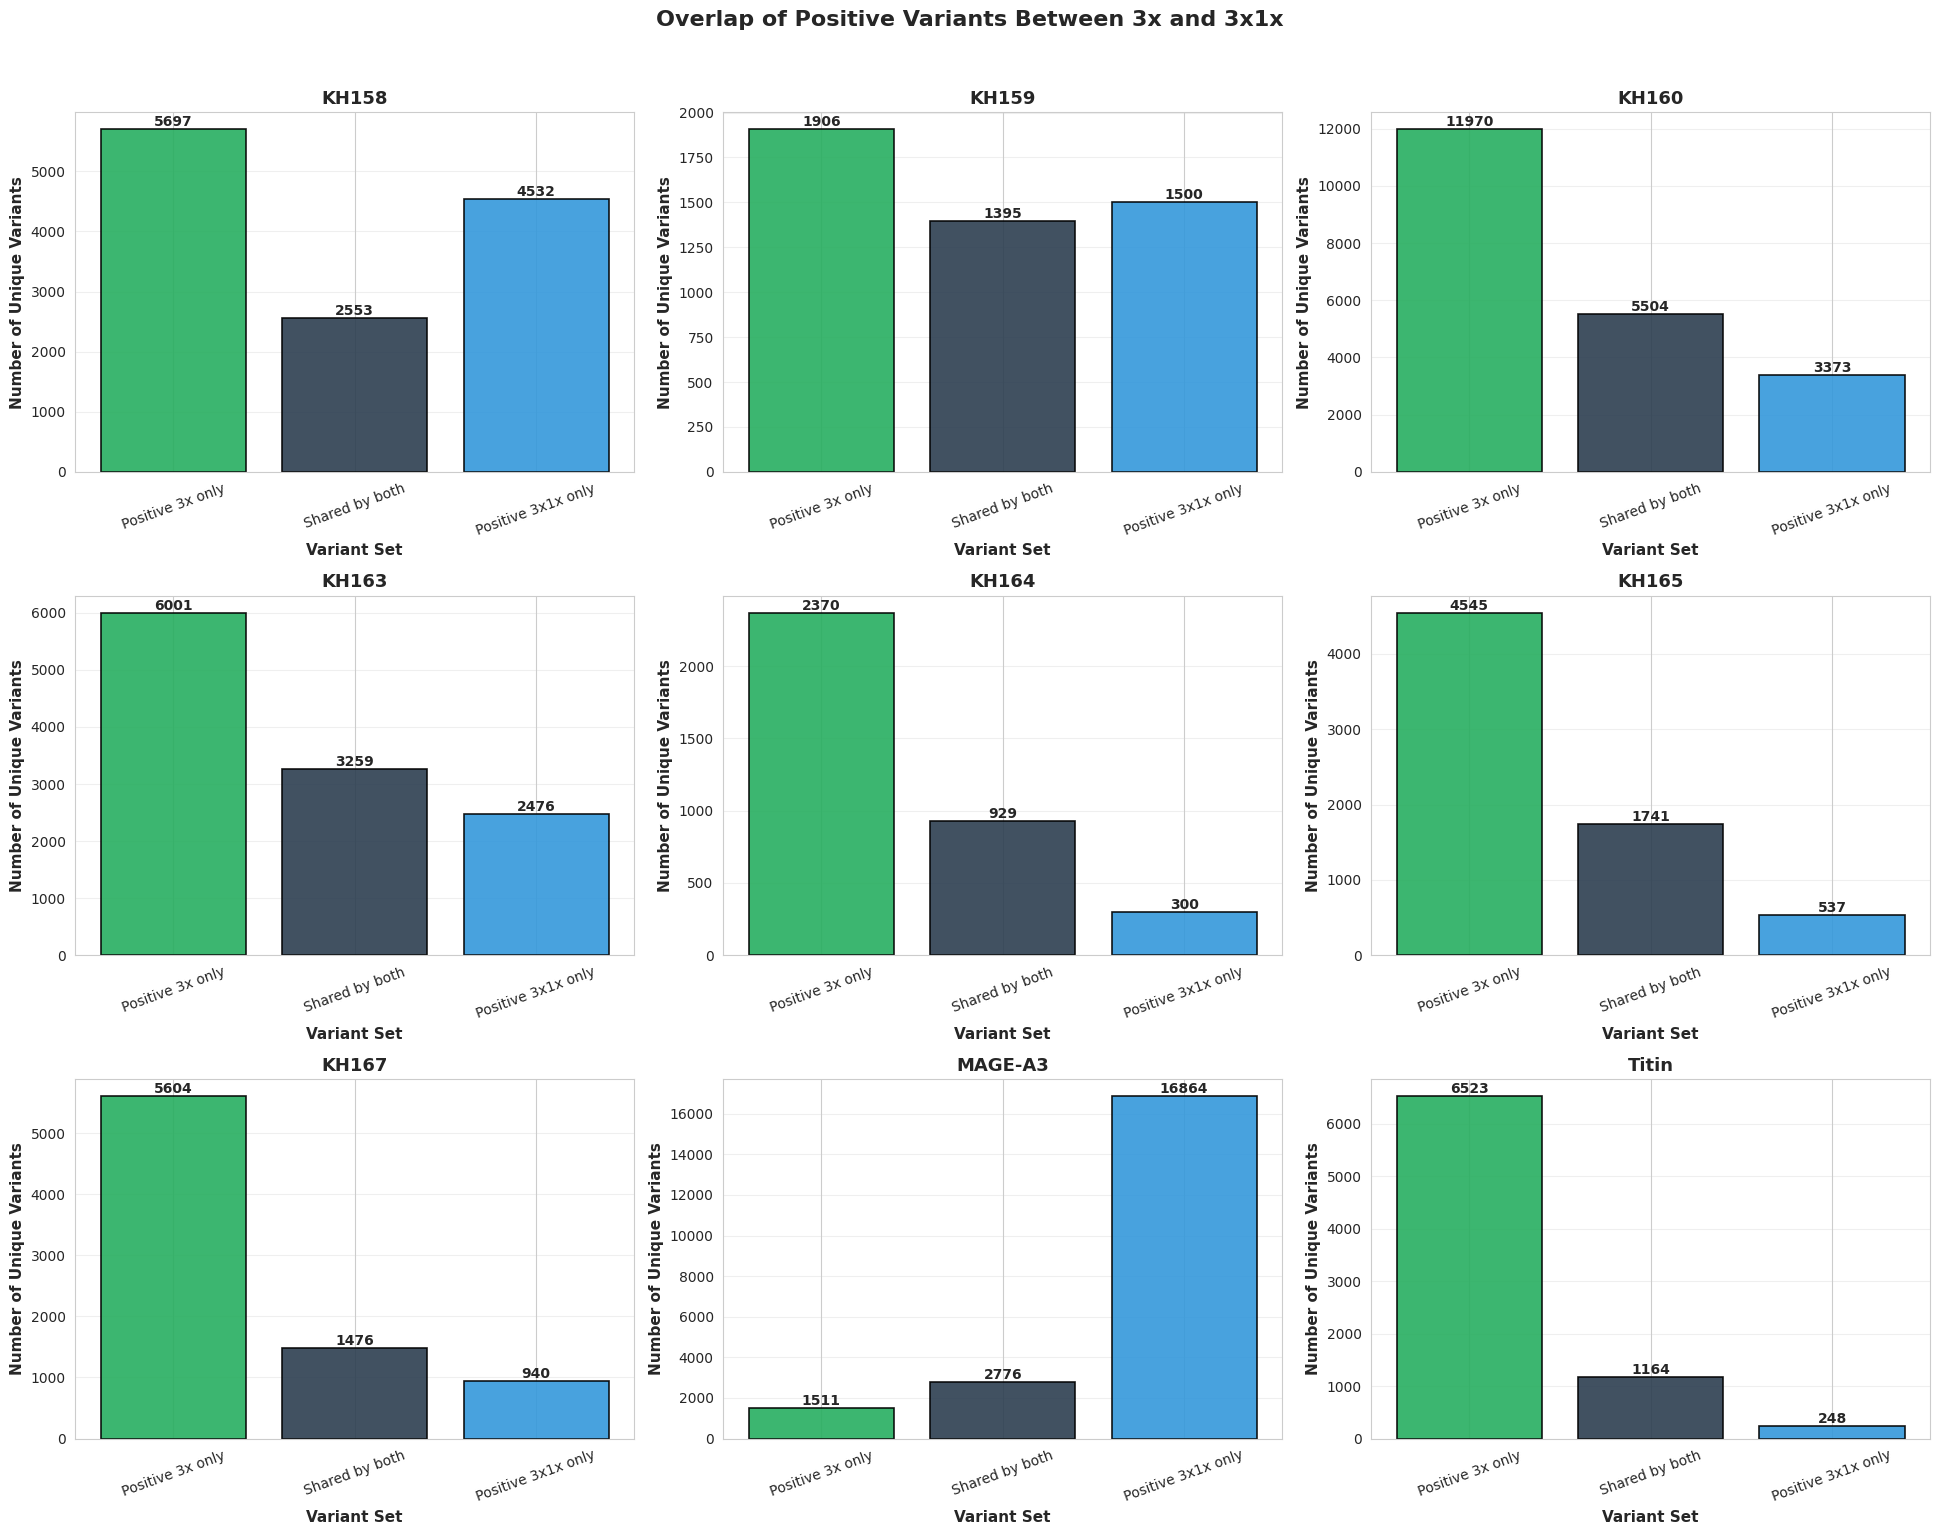

KH158:
  Positive 3x variants: 8250
  Positive 3x1x variants: 7085
  Shared variants: 2553
KH159:
  Positive 3x variants: 3301
  Positive 3x1x variants: 2895
  Shared variants: 1395
KH160:
  Positive 3x variants: 17474
  Positive 3x1x variants: 8877
  Shared variants: 5504
KH163:
  Positive 3x variants: 9260
  Positive 3x1x variants: 5735
  Shared variants: 3259
KH164:
  Positive 3x variants: 3299
  Positive 3x1x variants: 1229
  Shared variants: 929
KH165:
  Positive 3x variants: 6286
  Positive 3x1x variants: 2278
  Shared variants: 1741
KH167:
  Positive 3x variants: 7080
  Positive 3x1x variants: 2416
  Shared variants: 1476
MAGE-A3:
  Positive 3x variants: 4287
  Positive 3x1x variants: 19640
  Shared variants: 2776
Titin:
  Positive 3x variants: 7687
  Positive 3x1x variants: 1412
  Shared variants: 1164


In [4]:
def summarize_enrichment_overlap(df):
    pos3x_variants = set(df.loc[df["count_pos3x"] > 0, "aa_seq"])
    pos1x_variants = set(df.loc[df["count_pos1x"] > 0, "aa_seq"])
    shared_variants = pos3x_variants & pos1x_variants
    only_pos3x = pos3x_variants - pos1x_variants
    only_pos1x = pos1x_variants - pos3x_variants

    return pd.Series({
        "Positive 3x only": len(only_pos3x),
        "Shared by both": len(shared_variants),
        "Positive 3x1x only": len(only_pos1x),
    })

if not peptide_datasets:
    raise ValueError("peptide_datasets is empty. Add at least one pd.read_csv(...) entry in the loading cell.")

num_peptides = len(peptide_datasets)
ncols = min(3, num_peptides)
nrows = ceil(num_peptides / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6.5 * ncols, 5 * nrows),
    squeeze=False,
)
axes = axes.flatten()

colors = ["#27ae60", "#2c3e50", "#3498db"]

for ax, (peptide_name, peptide_df) in zip(axes, peptide_datasets.items()):
    summary_counts = summarize_enrichment_overlap(peptide_df)
    bars = ax.bar(
        summary_counts.index,
        summary_counts.values,
        color=colors,
        edgecolor="black",
        linewidth=1.2,
        alpha=0.9,
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    ax.set_title(peptide_name, fontsize=13, fontweight="bold")
    ax.set_ylabel("Number of Unique Variants", fontsize=11, fontweight="bold")
    ax.set_xlabel("Variant Set", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

for ax in axes[num_peptides:]:
    ax.axis("off")

fig.suptitle(
    "Overlap of Positive Variants Between 3x and 3x1x",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

for peptide_name, peptide_df in peptide_datasets.items():
    summary_counts = summarize_enrichment_overlap(peptide_df)
    pos3x_total = int((peptide_df["count_pos3x"] > 0).sum())
    pos1x_total = int((peptide_df["count_pos1x"] > 0).sum())
    shared_total = int(summary_counts["Shared by both"])
    print(f"{peptide_name}:")
    print(f"  Positive 3x variants: {pos3x_total}")
    print(f"  Positive 3x1x variants: {pos1x_total}")
    print(f"  Shared variants: {shared_total}")

# DMF5 dataset

Compare 1x positive enrichment vs 2x positive enrichment

In [6]:
peptide_DMF5_datasets = {
    "DRG01": pd.read_csv("../data/P3481_LUCA-TCRDMF5/variant_labeling/DRG01.variant_labeling.csv"),
    "DRG04": pd.read_csv("../data/P3481_LUCA-TCRDMF5/variant_labeling/DRG04.variant_labeling.csv"),
    "GIG01": pd.read_csv("../data/P3481_LUCA-TCRDMF5/variant_labeling/GIG01.variant_labeling.csv"),
    "GIG03": pd.read_csv("../data/P3481_LUCA-TCRDMF5/variant_labeling/GIG03.variant_labeling.csv"),
    "GIG04": pd.read_csv("../data/P3481_LUCA-TCRDMF5/variant_labeling/GIG04.variant_labeling.csv"),
    "GIG05": pd.read_csv("../data/P3481_LUCA-TCRDMF5/variant_labeling/GIG05.variant_labeling.csv"),
}

peptide_DMF5_2x_datasets = {
    "DRG01": pd.read_csv("../data/P3481_LUCA-TCRDMF5/variant_labeling_2x/DRG01.variant_labeling.csv"),
    "DRG04": pd.read_csv("../data/P3481_LUCA-TCRDMF5/variant_labeling_2x/DRG04.variant_labeling.csv"),
    "GIG01": pd.read_csv("../data/P3481_LUCA-TCRDMF5/variant_labeling_2x/GIG01.variant_labeling.csv"),
    "GIG03": pd.read_csv("../data/P3481_LUCA-TCRDMF5/variant_labeling_2x/GIG03.variant_labeling.csv"),
    "GIG04": pd.read_csv("../data/P3481_LUCA-TCRDMF5/variant_labeling_2x/GIG04.variant_labeling.csv"),
    "GIG05": pd.read_csv("../data/P3481_LUCA-TCRDMF5/variant_labeling_2x/GIG05.variant_labeling.csv"),
}

print(f"Loaded {len(peptide_DMF5_datasets)} peptide datasets")
for peptide_name, peptide_df in peptide_DMF5_datasets.items():
    print(f"{peptide_name}: shape={peptide_df.shape}")
    print(f"  columns={peptide_df.columns.tolist()}")

print(f"Loaded {len(peptide_DMF5_2x_datasets)} peptide datasets")
for peptide_name, peptide_df in peptide_DMF5_2x_datasets.items():
    print(f"{peptide_name}: shape={peptide_df.shape}")
    print(f"  columns={peptide_df.columns.tolist()}")

Loaded 6 peptide datasets
DRG01: shape=(223318, 17)
  columns=['aa_seq', 'count_lib', 'freq_lib', 'count_neg', 'freq_neg', 'count_pos3x', 'freq_pos3x', 'peptide', 'enrich_pos3x_vs_neg', 'enrich_pos3x_vs_lib', 'deplete_neg_lib', 'pos3x_vs_neg_status', 'pos3x_vs_lib_status', 'pos_vs_neg_status', 'pos_vs_lib_status', 'neg_vs_lib_status', 'specificity']
DRG04: shape=(223468, 17)
  columns=['aa_seq', 'count_lib', 'freq_lib', 'count_neg', 'freq_neg', 'count_pos3x', 'freq_pos3x', 'peptide', 'enrich_pos3x_vs_neg', 'enrich_pos3x_vs_lib', 'deplete_neg_lib', 'pos3x_vs_neg_status', 'pos3x_vs_lib_status', 'pos_vs_neg_status', 'pos_vs_lib_status', 'neg_vs_lib_status', 'specificity']
GIG01: shape=(226038, 17)
  columns=['aa_seq', 'count_lib', 'freq_lib', 'count_neg', 'freq_neg', 'count_pos3x', 'freq_pos3x', 'peptide', 'enrich_pos3x_vs_neg', 'enrich_pos3x_vs_lib', 'deplete_neg_lib', 'pos3x_vs_neg_status', 'pos3x_vs_lib_status', 'pos_vs_neg_status', 'pos_vs_lib_status', 'neg_vs_lib_status', 'specificit

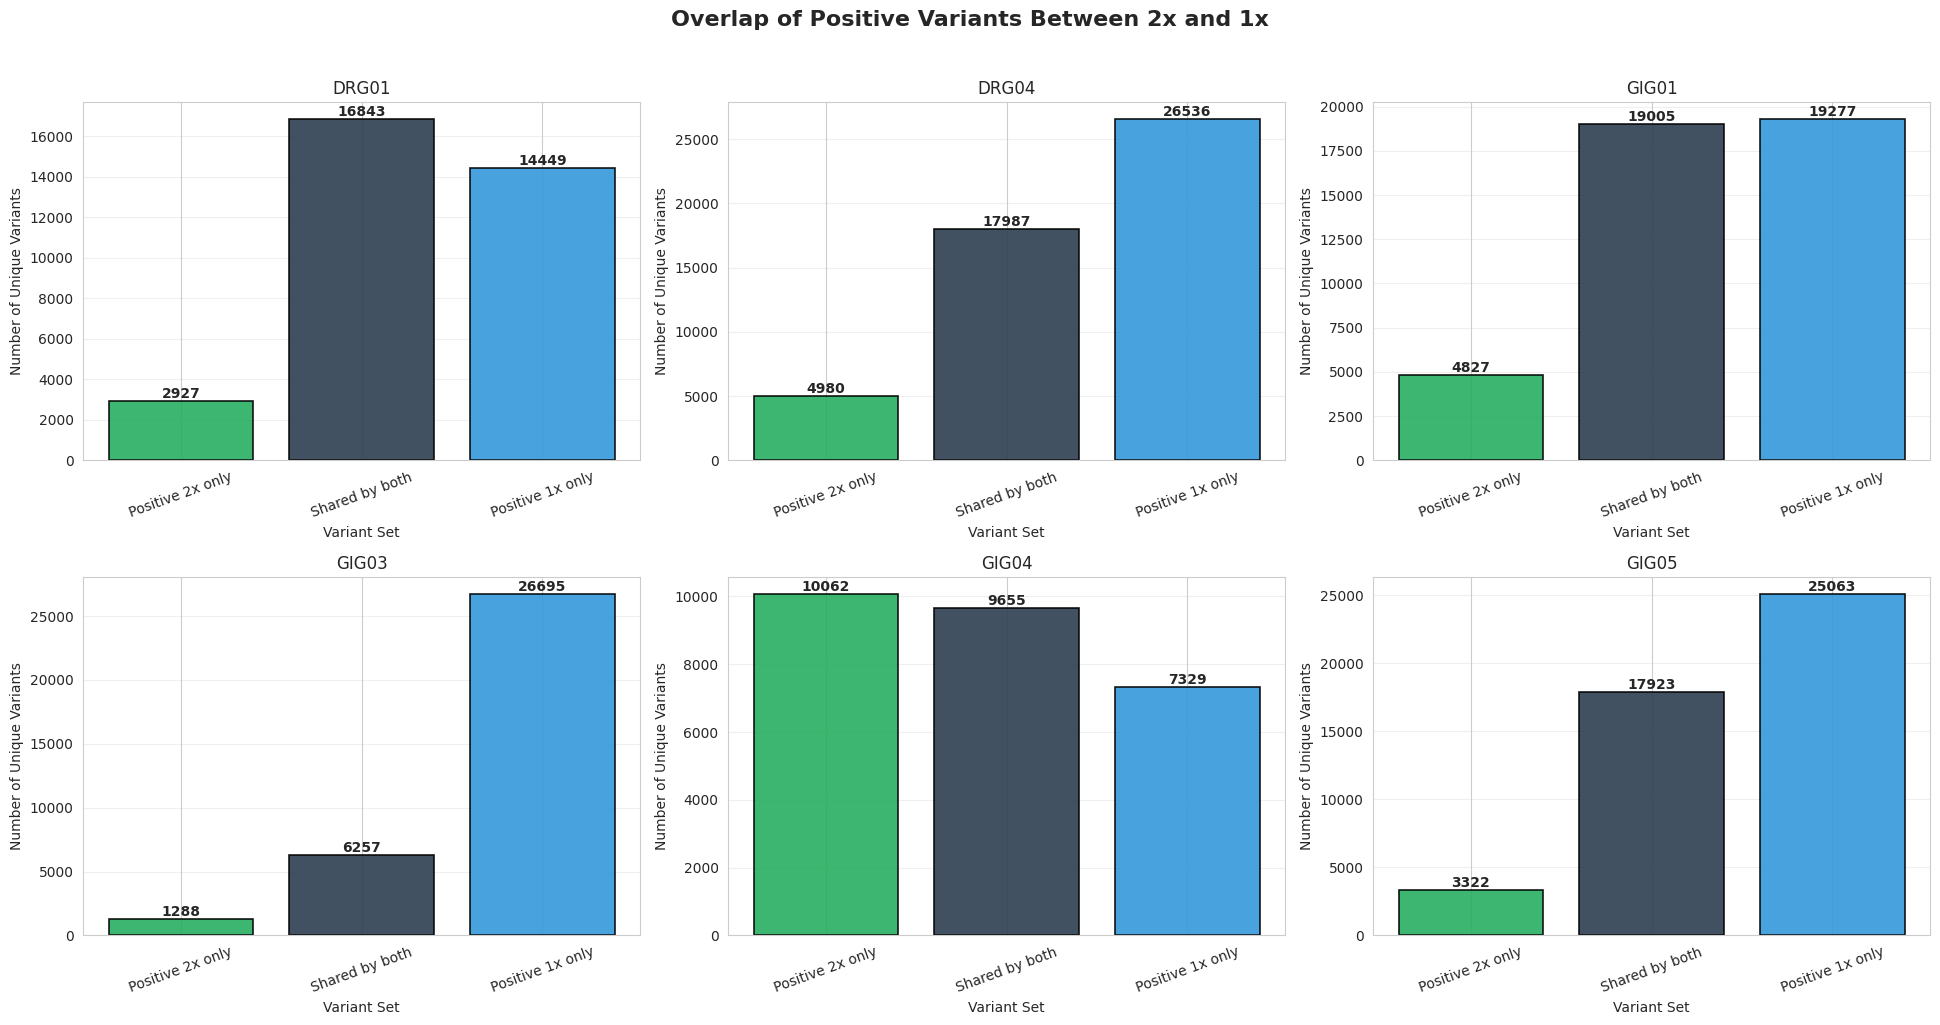

KeyError: 'count_pos2'

In [ ]:
from math import ceil
import pandas as pd
import matplotlib.pyplot as plt


def summarize_enrichment_overlap(df1, df2):
    pos2x_variants = set(df1.loc[df1["count_pos"] > 0, "aa_seq"])
    pos1x_variants = set(df2.loc[df2["count_pos3x"] > 0, "aa_seq"])

    shared_variants = pos2x_variants & pos1x_variants
    only_pos2x = pos2x_variants - pos1x_variants
    only_pos1x = pos1x_variants - pos2x_variants

    return pd.Series({
        "Positive 2x only": len(only_pos2x),
        "Shared by both": len(shared_variants),
        "Positive 1x only": len(only_pos1x),
    })


if not peptide_DMF5_datasets:
    raise ValueError("peptide_DMF5_datasets is empty.")

if not peptide_DMF5_2x_datasets:
    raise ValueError("peptide_DMF5_2x_datasets is empty.")


num_peptides = len(peptide_DMF5_datasets)
ncols = min(3, num_peptides)
nrows = ceil(num_peptides / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6.5 * ncols, 5 * nrows),
    squeeze=False,
)
axes = axes.flatten()

colors = ["#27ae60", "#2c3e50", "#3498db"]


# -----------------------------
# Plotting loop (fixed)
# -----------------------------
for (peptide_name, df_1x), ax in zip(peptide_DMF5_datasets.items(), axes):

    df_2x = peptide_DMF5_2x_datasets[peptide_name]

    summary_counts = summarize_enrichment_overlap(df_2x, df_1x)

    bars = ax.bar(
        summary_counts.index,
        summary_counts.values,
        color=colors,
        edgecolor="black",
        linewidth=1.2,
        alpha=0.9,
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    ax.set_title(peptide_name)
    ax.set_ylabel("Number of Unique Variants")
    ax.set_xlabel("Variant Set")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)


# turn off unused axes
for ax in axes[num_peptides:]:
    ax.axis("off")


fig.suptitle(
    "Overlap of Positive Variants Between 2x and 1x",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()


# -----------------------------
# Summary print (fixed)
# -----------------------------
for peptide_name, df_1x in peptide_DMF5_datasets.items():

    df_2x = peptide_DMF5_2x_datasets[peptide_name]

    summary_counts = summarize_enrichment_overlap(df_2x, df_1x)

    pos2x_total = int((df_2x["count_pos"] > 0).sum())
    pos1x_total = int((df_1x["count_pos3x"] > 0).sum())
    shared_total = int(summary_counts["Shared by both"])

    print(f"{peptide_name}:")
    print(f"  Positive 2x variants: {pos2x_total}")
    print(f"  Positive 1x variants: {pos1x_total}")
    print(f"  Shared variants: {shared_total}")